# Final Exam (part 1) - Computational Physics I

### Deadline: Thursday 5 June 2025 (by 23h59)
### Credits: 10 points

### Please keep the structure provided below and submit an organised notebook with clear answers to each item.

## Name: Silva Alejandro

## 1. Fourier analysis: removing Herringbone MRI artifacts

This problem consist of using Fourier analysis to remove undesired Herringbone artifacts from magnetic resonance images (MRI).

The file provided below **herringbone-mri-artifact.jpg** contains a brain MRI image affected by the Herringbone artifact. This artifact can be produced by electromagnetic spikes by gradient coils, a fluctuating power supply, or radiofrequency pulse discrepancies during MRI scanning. In real space, the regularly spaced stripes resemble the appearance of a fabric with a herringbone pattern (which gives the artifact its name). In this image, the artifact covers the entire image with multiple diagonal stripes, which would be seen as spike artifacts in Fourier space. Your task is to remove them.

#### Download the image file:
https://github.com/wbandabarragan/physics-teaching-data/blob/main/2D-data/herringbone-mri-artifact.jpg

#### Reference:
Case courtesy of Frank Gaillard, <a href="https://radiopaedia.org/?lang=us">Radiopaedia.org</a>. From the case <a href="https://radiopaedia.org/cases/19695?lang=us">rID: 19695</a>

### Requirements
The following libraries are required to run this notebook.

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import scienceplots

In [2]:
# Set plots style
plt.style.use(['science', 'notebook', 'no-latex'])

## Image I/O:

### (a) Inspect the file. Then, write a python function that reads the data from the **herringbone-mri-artifact.jpg** file, and returns its 3 layers (channels) as numpy arrays.

In [ ]:
def read_im(filename):
    """
    This function reads an RGB image and returns its 3 layers individually as numpy arrays inside a tuple object.
    --------------------------------
    Input:
    filename -> str, path to the image.
    --------------------------------
    Outputs:
    im_layers -> tuple, it contains the layers of the image as numpy arrays.
    im_arr -> numpy array, the original full image.
    --------------------------------
    Author: AlejoS
    Date: 01/06/2025
    """
    # Read the image
    img = Image.open(filename)

    # Convert to an array
    im_arr = np.array(img)

    # Select RGB layers and store them in a tuple
    im_layers = (im_arr[:, :, 0], im_arr[:, :, 1], im_arr[:, :, 2])
    return im_layers, im_arr

### (b) Call your function, select a single channel and make a map of it. Identify and label the Herringbone artifacts on the image using small arrows.

In [4]:
filename = "./data/herringbone-mri-artifact.jpg" #change to your image path
# Call our function
im_layers, image = read_im(filename)
# Safe check
#print(im_layers[0].shape, im_layers[1].shape, im_layers[2].shape)

# Select one of the layers
g_layer = im_layers[1] # Green layer

# Intensity values
print(np.min(g_layer), np.max(g_layer))

14 255


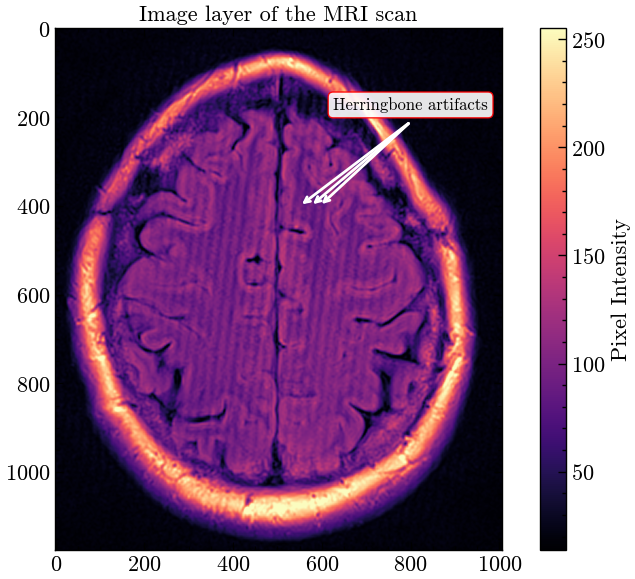

In [5]:
# Plotting one layer
plt.figure(figsize = (8, 6))
plt.imshow(g_layer, cmap = 'magma', vmin = 14, vmax = 255)

# Legend
plt.colorbar(label = "Pixel Intensity")
plt.title("Image layer of the MRI scan")
# Annotations
plt.annotate(
    "",
    xy=(550, 400), xytext=(800, 210),
    arrowprops = dict(arrowstyle = "->", color = "white", lw = 2))
plt.annotate(
    "",
    xy=(575, 400), xytext=(800, 210),
    arrowprops = dict(arrowstyle = "->", color = "white", lw = 2))

plt.annotate(
    "",
    xy=(595, 400), xytext=(800, 210),
    arrowprops = dict(arrowstyle = "->", color = "white", lw = 2))

plt.text(
    800, 190, "Herringbone artifacts", fontsize=12, color="black", ha="center", va="bottom",
    bbox=dict(boxstyle="round,pad=0.3", edgecolor="red", facecolor="white", alpha=0.9)
)
# Show
plt.tight_layout()
plt.show()

The herringbone artifacts are the regularly spaced stripes. They're not vertical but rather at an angle.

## 2D Fourier transform:

### (c) Create a function that Fourier transforms this image and returns the Fourier image and the correct frequencies.

In [6]:
def fft_2d(im_layer):
    """
    This function computes the 2D Fourier Transform of an image layer.
    --------------------------------
    Input:
    im_layer -> array, the image layer to be transformed.
    --------------------------------
    Outputs:
    norm_sh -> array, normalized 2D Fourier Transform of the image layer.
    freqs_X, freqs_Y -> arrays, frequency coordinates in Fourier space. They're inside a tuple.
    im_fft_sh -> array, shifted 2D Fourier Transform of the image layer.
    --------------------------------
    Author: AlejoS
    Date: 01/06/2025
    """
    # Compute the 2D Fourier Transform
    im_fft = np.fft.fft2(im_layer)

    # Shift low frequencies to the center
    im_fft_sh = np.fft.fftshift(im_fft)

    # Get just the real values
    norm_sh = np.abs(im_fft_sh)

    # Normalize the Fourier Transform
    norm_sh *= (2/norm_sh.size)

    # Get the frequency coordinates
    freqs_x = np.fft.fftfreq(im_layer.shape[1])

    freqs_y = np.fft.fftfreq(im_layer.shape[0])

    # Creating the mesh:
    freqs_X, freqs_Y = np.meshgrid(sorted(freqs_x), sorted(freqs_y))

    # Return the Fourier Transform and the frequency coordinates
    return (freqs_X, freqs_Y), norm_sh, im_fft_sh

### (d) Call your function in (c), and make a two-panel figure with the original image on the left and a labeled 2D plot of its Fourier image on the right. Identify and label the Herringbone artifacts on the Fourier image.

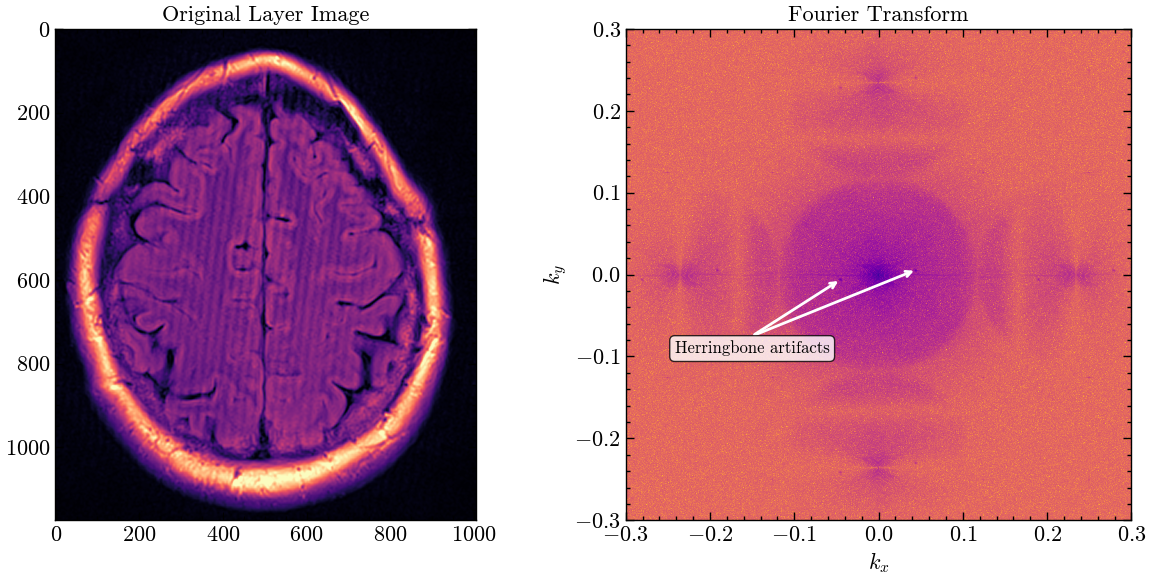

In [7]:
# Calling our function
freqs, ft_1, ft_1_sh = fft_2d(g_layer)

# Create the figure and subplots
fig, ax = plt.subplots(1, 2, figsize =(12, 6)) # 1 row, 2 columns

# Plotting the original image
ax[0].imshow(g_layer, cmap = 'magma', vmin = 14, vmax = 255)
ax[0].set_title("Original Layer Image")

# Plotting the Fourier Transform
ax[1].pcolor(freqs[0], freqs[1],  np.log10(ft_1), cmap = "plasma_r")
ax[1].set_xlim(-0.3, 0.3)
ax[1].set_ylim(-0.3, 0.3)
ax[1].set_xlabel(r"$k_x$")
ax[1].set_ylabel(r"$k_y$")
ax[1].set_title("Fourier Transform")

# Annotations
ax[1].annotate(
    "",
    xy=(-0.045, -0.006), xytext=(-0.15, -0.075),
    arrowprops = dict(arrowstyle = "->", color = "white", lw = 2))
ax[1].annotate(
    "",
    xy=(0.045, 0.006), xytext=(-0.15, -0.075),
    arrowprops = dict(arrowstyle = "->", color = "white", lw = 2))
ax[1].text(
    -0.15, -0.1, "Herringbone artifacts", fontsize=12, color="black", ha="center", va="bottom",
    bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.show()


### (e) Briefly comment, how do the image artifacts look in Fourier space? 

The herringbone artifacts look like small disks in Fourier space. We observe two distinct artifacts in the low-frequency region of the spectrum, along with two above, two below, and two on each side. Interestingly, on each case, both are symmetric about the $k_x$ axis.

## Masking and filtering:

### (f) Create an appropriate mask for the Fourier image that matches the features associated with the Herringbone artifacts. Plot the mask.

Let's first try removing the artifacts near the centre of the Fourier map.

In [8]:
def mask_img(im_layer_ft, boolean):
    """
    This function constructs a mask according to the FT of one of the image layers to try removing herringbone artifacts.
    --------------------------------
    Inputs:
    im_layer_ft -> array, the FT map to be masked.
    boolean -> bool, if True, it shows the mask.
    --------------------------------
    Output:
    mask_im -> array, the mask.
    --------------------------------
    Author: AlejoS
    Date: 01/06/2025
    """
    # Construct the mask
    mask_1 = Image.new(mode="RGB", size=(im_layer_ft.shape[1], im_layer_ft.shape[0]))

    # Disks radius
    r_off = 7 #many attempts to find the best value

    draw = ImageDraw.Draw(mask_1)

    # Use pillow to draw the disks, many attempts to place the disks where they belong
    # First disk
    x1_center = im_layer_ft.shape[1] // 2 + 40  
    y1_center = im_layer_ft.shape[0] // 2 + 5 

    draw.ellipse((
        x1_center - r_off, y1_center - r_off,
        x1_center + r_off, y1_center + r_off),
        fill=(255, 0, 0), outline=(0, 0, 0)
        )      

    # Second disk
    x2_center = im_layer_ft.shape[1] // 2 - 45 
    y2_center = im_layer_ft.shape[0] // 2 - 7  

    draw.ellipse((
        x2_center - r_off, y2_center - r_off,
        x2_center + r_off, y2_center + r_off),
        fill=(255, 0, 0), outline=(0, 0, 0)
    )
    # Binary image
    mask = np.array(mask_1)[:, :, 0]//255
    mask_2 = - mask + 1

    # Plotting the mask
    plt.figure(figsize=(8, 6))
    plt.imshow(mask_2, cmap='magma')
    plt.title("Mask for Herringbone Artifacts")
    plt.colorbar(label="Intensity")
    plt.gca().invert_yaxis()   # to match the FT image orientation
    if boolean:
        plt.show()
    plt.close()

    return mask_2

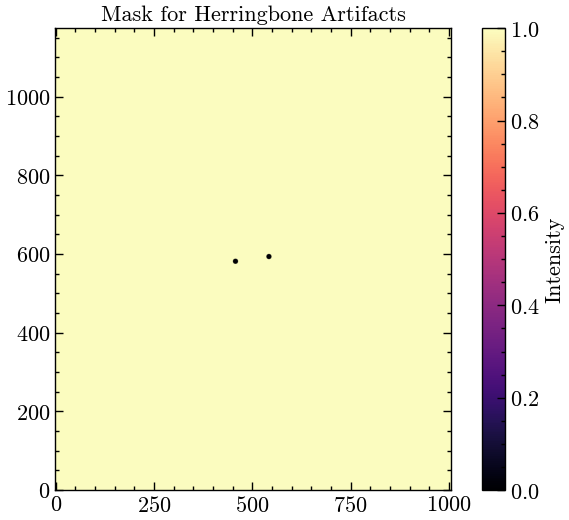

In [9]:
mask = mask_img(ft_1, True)

### (g) Use your mask from (f) to remove the Herringbone artifacts from the Fourier image.

In [10]:
def remove_artifacts(mag_ft, ft_sh, mask, boolean):
    """
    This function removes the herringbone artifacts from the image layer using the mask.
    --------------------------------
    Inputs:
    mag_ft -> array, the real values of the FT map of the image layer.
    ft_sh -> array, the shifted FT map of the image layer.
    mask -> array, the mask to be applied.
    boolean -> bool, if True, it shows the plots.
    --------------------------------
    Output:
    im_masked -> array, the masked FT map.
    --------------------------------
    Author: AlejoS
    Date: 01/06/2025
    """
    # Apply the mask to the FT map
    im_masked = ft_sh * mask

    # Get the real part
    im_masked_real = np.abs(im_masked)

    # Plotting
    # Create the figure and subplots
    fig, ax = plt.subplots(1, 2, figsize =(12, 6)) # 1 row, 2 columns

    # Plotting the original FT image
    ax[0].pcolor(np.log10(mag_ft), cmap = 'magma')
    ax[0].set_title("FT of the Image Layer")

    # Plotting the masked FT image
    ax[1].pcolor(np.log10(im_masked_real), cmap = "magma")
    ax[1].set_title("Masked FT of the Image Layer")

    plt.tight_layout()
    if boolean:
        plt.show()
    plt.close()

    return im_masked

/tmp/ipykernel_23262/3440725004.py:32: RuntimeWarning: divide by zero encountered in log10
  ax[1].pcolor(np.log10(im_masked_real), cmap = "magma")


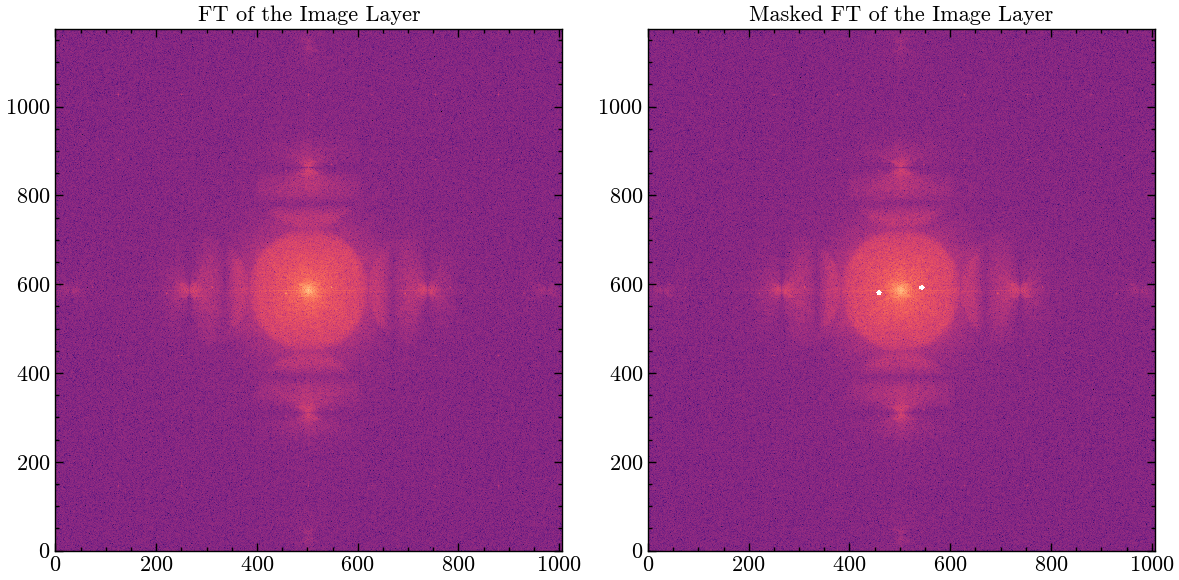

In [11]:
layer2_masked = remove_artifacts(ft_1, ft_1_sh, mask, True)

### (h) Inverse Fourier transform the masked Fourier image and make a two-panel figure showing the original image on the left and the new filtered image (without the Herringbone artifacts) on the right.

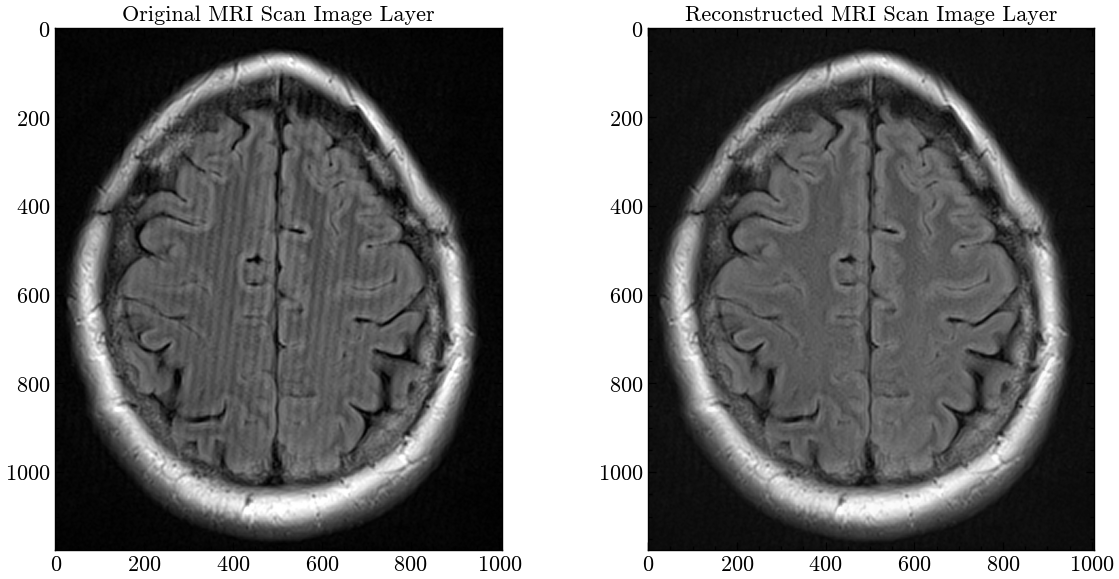

In [12]:
# Unshift, perform the inverse 2D FFT and get the real values
g_filtered = np.abs(np.fft.ifft2(np.fft.ifftshift(layer2_masked)))

# Plotting
# Create the figure and subplots
fig, ax = plt.subplots(1, 2, figsize =(12, 6)) # 1 row, 2 columns

# Plotting the original image layer
ax[0].imshow(g_layer, cmap = 'gray')
ax[0].set_title("Original MRI Scan Image Layer")

# Plotting the masked filtered image layer
ax[1].imshow(g_filtered, cmap = "gray")
ax[1].set_title("Reconstructed MRI Scan Image Layer")

plt.tight_layout()
plt.show()

It was enough to just remove the disks near the centre in Fourier space.

## Artifact-free image:

### (i) Create a function that combines all the previous steps. The function should receive an input image channel, apply the Fourier filter to it and return the original and the filtered channel images. Call and apply your filter function to the other two channels of the **herringbone-mri-artifact.jpg** image.

In [13]:
def clean_mri_artifact(im_layer, boolean):
    """
    This function reads an image, applies the Fourier Transform, masks it to remove herringbone artifacts,
    and reconstructs the image layer.
    --------------------------------
    Inputs:
    im_layer -> array, the image layer.
    boolean -> bool, to show the images.
    --------------------------------
    Output:
    im_filtered -> array, the reconstructed image layer without artifacts.
    --------------------------------
    Author: AlejoS
    Date: 02/06/2025
    """
    # Let's call our functions
    # Apply the Fourier Transform
    freqs, ft, ft_sh = fft_2d(im_layer)

    # Create the mask
    mask = mask_img(ft, False)

    # Remove artifacts
    im_filtered = remove_artifacts(ft, ft_sh, mask, False)

    # Unshift, perform the inverse 2D FFT and get the real values
    im_filtered = np.abs(np.fft.ifft2(np.fft.ifftshift(im_filtered)))

    # Plotting
    if boolean:
        # Create the figure and subplots
        fig, ax = plt.subplots(1, 2, figsize =(12, 6)) # 1 row, 2 columns

        # Plotting the original image layer
        ax[0].imshow(im_layer, cmap = 'plasma')
        ax[0].set_title("Original MRI Scan Image Layer")

        # Plotting the reconstructed image layer
        ax[1].imshow(im_filtered, cmap = "plasma")
        ax[1].set_title("Reconstructed MRI Scan Image Layer")

    plt.tight_layout()
    plt.show()
    plt.close()

    return im_filtered

In [14]:
# R channel
r_layer = im_layers[0]  # Red layer 
# B channel
b_layer = im_layers[2]  # Blue layer

# Calling the function for each layer
r_filtered = clean_mri_artifact(r_layer, False)
#g_filtered = clean_mri_artifact(g_layer, False) #already done
b_filtered = clean_mri_artifact(b_layer, False)

/tmp/ipykernel_23262/3440725004.py:32: RuntimeWarning: divide by zero encountered in log10
  ax[1].pcolor(np.log10(im_masked_real), cmap = "magma")


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

### (j) Using the output clean images from (i), reconstruct the 3-layered image and make a two panel figure showing the original 3-layered image and your new artifact-free 3-layered image. Briefly comment on your results.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [4..260].


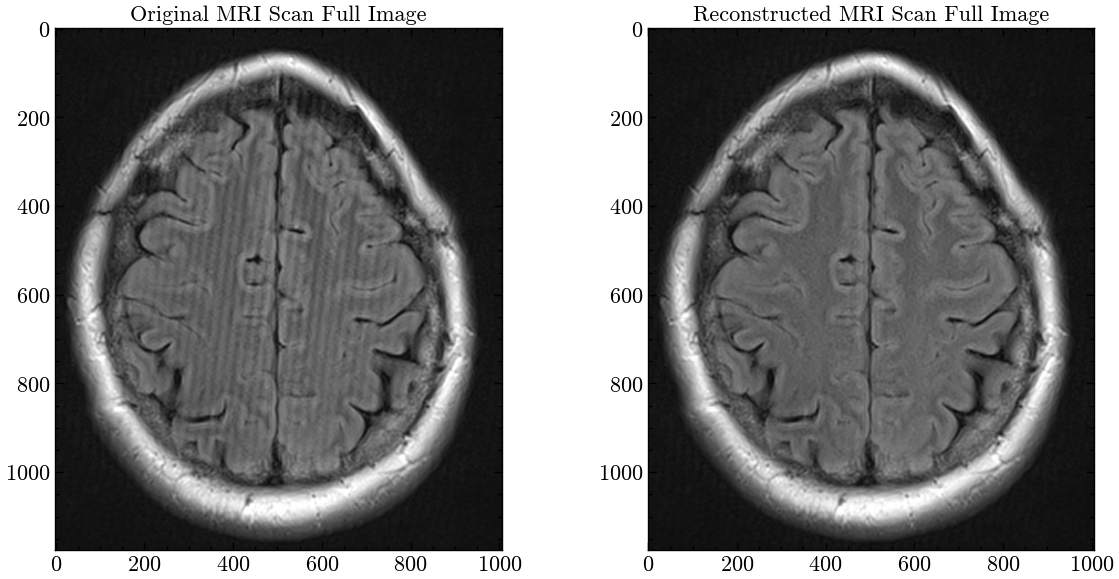

In [ ]:
# Reconstruct the image from the filtered layers
# Create an empty array for the reconstructed image
im_reconstructed = np.zeros((r_filtered.shape[0], r_filtered.shape[1], 3), dtype = int) #here, pixel values are integers
# Assign cleaned channels
im_reconstructed[:, :, 0] = r_filtered
im_reconstructed[:, :, 1] = g_filtered
im_reconstructed[:, :, 2] = b_filtered
# Safe check
#print(im_reconstructed.shape)

# Plotting
# Create the figure and subplots
fig, ax = plt.subplots(1, 2, figsize =(12, 6)) # 1 row, 2 columns

# Plotting the original image
ax[0].imshow(image, cmap = 'Greys')
ax[0].set_title("Original MRI Scan Full Image")

# Plotting the reconstructed image
ax[1].imshow(im_reconstructed, cmap = "Greys")
ax[1].set_title("Reconstructed MRI Scan Full Image")

plt.tight_layout()
plt.show()